# Project: Bank Marketing Modeling & Prediction

#### Owner 
- Name: Oyeleso Tawakalt O.
- Email: tawakaltoyeleso01@gmail.com

#### Objective
Predicting whether client will subscribe or not to product (bank term deposit).


#### Feature Engineering
We will reload the raw(original) dataset to avoid data leakage.
    
All preprocessing (handling missing values, encoding, scaling, etc.) will now be learned only from the training set using a pipeline.

In [6]:
# import the necessary libraries

import pandas as pd
import numpy as ps
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
#Loading datasets

bank_m_df = pd.read_csv('C:\\Users\\Tawakalt.Oyeleso\\Desktop\\Tawakalt Docs\\Projects\\2026\\analyzed\\bank_marketing_prediction\\data\\bank-full.csv', sep = ";")

In [8]:
#checking top data
bank_m_df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [9]:
#checking data types

bank_m_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [10]:
#summary statistics
bank_m_df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [11]:
#summary statistics for all column
bank_m_df.describe(include = 'all')

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
count,45211.000000,45211,45211,45211,45211,45211.000000,45211,45211,45211,45211.000000,45211,45211.000000,45211.000000,45211.000000,45211.000000,45211,45211
unique,NaN,12,3,4,2,NaN,2,2,3,NaN,12,NaN,NaN,NaN,NaN,4,2
top,NaN,blue-collar,married,secondary,no,NaN,yes,no,cellular,NaN,may,NaN,NaN,NaN,NaN,unknown,no
freq,NaN,9732,27214,23202,44396,NaN,25130,37967,29285,NaN,13766,NaN,NaN,NaN,NaN,36959,39922
mean,40.936210,NaN,NaN,NaN,NaN,1362.272058,NaN,NaN,NaN,15.806419,NaN,258.163080,2.763841,40.197828,0.580323,NaN,NaN
std,10.618762,NaN,NaN,NaN,NaN,3044.765829,NaN,NaN,NaN,8.322476,NaN,257.527812,3.098021,100.128746,2.303441,NaN,NaN
min,18.000000,NaN,NaN,NaN,NaN,-8019.000000,NaN,NaN,NaN,1.000000,NaN,0.000000,1.000000,-1.000000,0.000000,NaN,NaN
25%,33.000000,NaN,NaN,NaN,NaN,72.000000,NaN,NaN,NaN,8.000000,NaN,103.000000,1.000000,-1.000000,0.000000,NaN,NaN
50%,39.000000,NaN,NaN,NaN,NaN,448.000000,NaN,NaN,NaN,16.000000,NaN,180.000000,2.000000,-1.000000,0.000000,NaN,NaN
75%,48.000000,NaN,NaN,NaN,NaN,1428.000000,NaN,NaN,NaN,21.000000,NaN,319.000000,3.000000,-1.000000,0.000000,NaN,NaN


In [12]:
#checking for duplicate values 
bank_m_df.duplicated().sum()

0

In [13]:
#checking for missing values 

bank_m_df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

##### There is no missing value in the dataset

In [14]:
#understanding target before modeling

print(bank_m_df['y'].unique())
print(bank_m_df['y'].nunique())

['no' 'yes']
2


### Identifying problem type 
The target variable 'y', is categorical (yes/no), therefore this is a classification problem.


Binary Classification
- Target variable: 'y'
- "yes" → customer subscribed
- "no" → customer did not subscribe

#### Identifying feature types
- numeric features:
      - age, balance, day, duration,campaign, pdays, previous
- categorical features:
      - job, marital, education, contact, month
- Binary features(Treat as numeric 0/1):
      - default, housing, loan

#### Train-test Split Data

In [15]:
from sklearn.model_selection import train_test_split

# X = feature matrix, y = target
X = bank_m_df.drop('y', axis = 1)
y = bank_m_df['y']

#split to 80%, 20%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42, stratify =y)

In [16]:
#identifying numerical features
numeric_features = X_train.select_dtypes(include = ['int64', 'float64']).columns.tolist()

print("Numeric Features are:", numeric_features)

Numeric Features are: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


In [17]:
#detecting outliers for numerical features

#IQR Method
for col in numeric_features:
    Q3 = X_train[col].quantile(0.75)
    Q1 = X_train[col].quantile(0.25)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = X_train[(X_train[col] < lower_bound) | (X_train[col] > upper_bound)]

    percentage = (len(outliers) / len(X_train)) * 100

    print(f"{col}: {len(outliers)} outliers ({percentage:.2f}%)")


age: 394 outliers (1.09%)
balance: 3770 outliers (10.42%)
day: 0 outliers (0.00%)
duration: 2632 outliers (7.28%)
campaign: 2465 outliers (6.82%)
pdays: 6584 outliers (18.20%)
previous: 6584 outliers (18.20%)


##### 
- The analysis shows that several numerical features, particularly pdays and previous, contain a high proportion of outliers, indicating strong skewness. 
- Features like balance, duration, and campaign also exhibit moderate skewness. 
- In contrast, age and day show minimal or no outliers.


- Based on these findings, skewed features will require transformation (such as log transformation) to reduce the impact of extreme values and improve model performance.

In [18]:
#detecting skew 
skew_values = X_train[numeric_features].skew()

skew_values = skew_values.sort_values(ascending=False)
print(skew_values)

previous    45.034399
balance      8.340204
campaign     4.941861
duration     3.210882
pdays        2.616298
age          0.693738
day          0.093389
dtype: float64


######
- Most numerical features in the dataset are right-skewed, especially previous, balance, campaign, duration, and pdays. 
These features contain extreme values (outliers) that could affect model performance, particularly for algorithms sensitive to skewed distributions such as logistic regression. 

- Features like age and day are nearly symmetric and don’t require transformation.

In [19]:
skewed_features = skew_values[skew_values > 1].index.tolist()
print("Highly skewed features:", skewed_features)

Highly skewed features: ['previous', 'balance', 'campaign', 'duration', 'pdays']


In [20]:
# log transforming the skewed features
import numpy as np

for col in skewed_features:
    if (X_train[col] < 0).any():
        # Shift values to make them positive
        shift = abs(X_train[col].min()) + 1
        X_train[col] = np.log1p(X_train[col] + shift)
        X_test[col] = np.log1p(X_test[col] + shift)
    else:
        X_train[col] = np.log1p(X_train[col])
        X_test[col] = np.log1p(X_test[col])

In [21]:
# Check how skewness changed
skew_values_post = X_train[skewed_features].skew().sort_values(ascending=False)
print("Skewness after log transformation:\n", skew_values_post)

Skewness after log transformation:
 previous    2.537646
pdays       1.729478
campaign    1.327986
balance     1.135241
duration   -0.451711
dtype: float64


##### 
The log transformation successfully reduced the impact of extreme outliers in the highly skewed numerical features. 
Features like previous, balance, campaign, and duration now have much lower skew values, making them more suitable for modeling. 
                                                                                                                  
Some right-skew remains for previous and pdays, but the extreme influence of outliers has been significantly minimized.

In [22]:
X_train.head(10)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
24001,36,technician,divorced,secondary,no,9.091782,no,no,telephone,29,aug,4.948760,1.098612,0.693147,0.000000,unknown
43409,24,student,single,secondary,no,9.404838,no,no,cellular,5,apr,6.811244,1.609438,5.236442,2.079442,failure
20669,44,technician,single,secondary,no,9.019785,yes,no,cellular,12,aug,7.459339,1.609438,0.693147,0.000000,unknown
18810,48,unemployed,married,secondary,no,8.989818,no,no,telephone,31,jul,3.583519,2.484907,0.693147,0.000000,unknown
23130,38,technician,married,secondary,no,9.021357,no,no,cellular,26,aug,4.060443,2.397895,0.693147,0.000000,unknown
15058,48,blue-collar,married,secondary,no,9.162620,no,yes,cellular,17,jul,7.066467,0.693147,0.693147,0.000000,unknown
15908,50,management,married,tertiary,no,9.420277,yes,no,cellular,22,jul,5.204007,2.484907,0.693147,0.000000,unknown
30424,46,services,married,tertiary,no,8.887515,no,yes,cellular,5,feb,4.859812,0.693147,0.693147,0.000000,unknown
9998,46,services,married,tertiary,no,9.047233,no,no,unknown,9,jun,6.100319,1.098612,0.693147,0.000000,unknown
14935,45,admin.,married,secondary,no,9.020269,no,no,cellular,16,jul,5.361292,1.098612,0.693147,0.000000,unknown


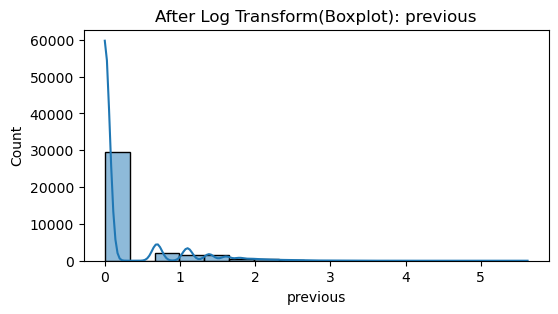

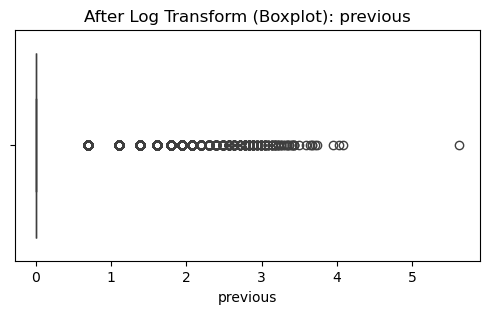

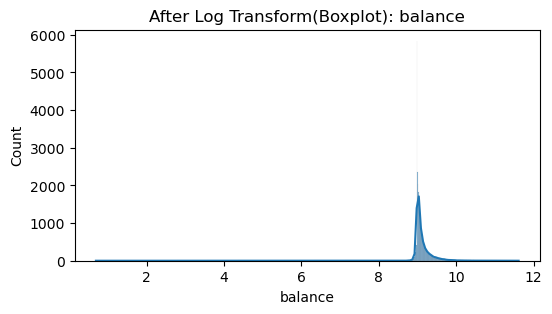

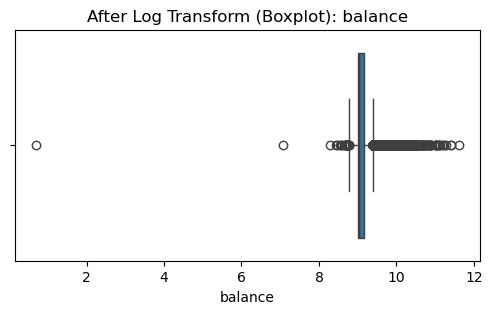

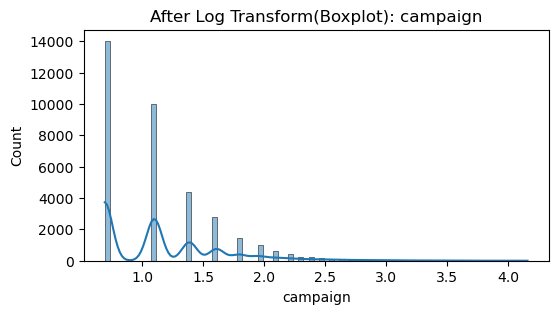

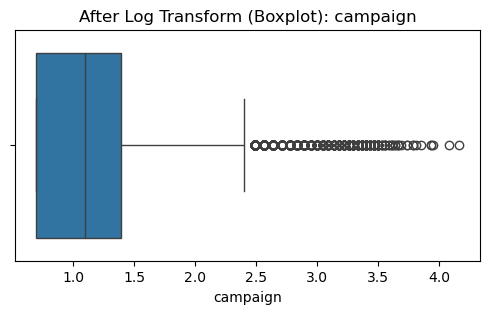

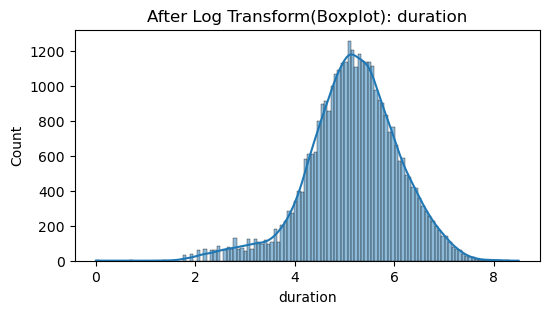

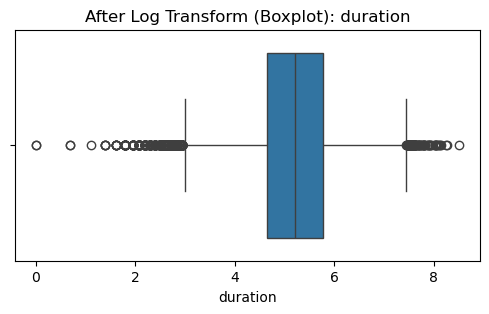

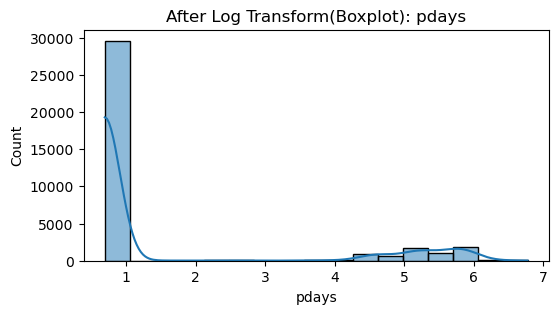

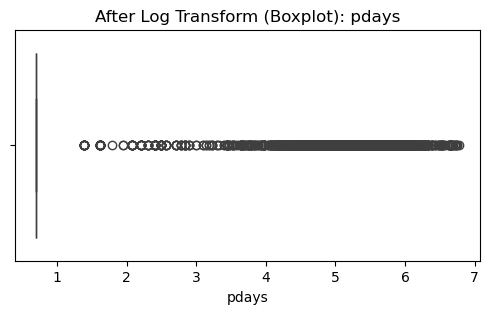

In [23]:
#visualize

import matplotlib.pyplot as plt
import seaborn as sns

for col in skewed_features:
    plt.figure(figsize=(6,3))
    sns.histplot(X_train[col], kde=True)
    plt.title(f'After Log Transform(Boxplot): {col}')
    plt.show()
    
    plt.figure(figsize=(6,3))
    sns.boxplot(x=X_train[col])
    plt.title(f'After Log Transform (Boxplot): {col}')
    plt.show()

In [24]:
# checking skew for test data
X_test[skewed_features].skew()

previous    2.431199
balance     2.915129
campaign    1.319404
duration   -0.464211
pdays       1.707821
dtype: float64

#####
- After log transformation, the test set shows reduced skew in all numeric features, similar to the training set. 

- Some differences remain for balance due to extreme high values in the test set, but overall, the distributions are now much more comparable. 

- This ensures that models trained on X_train will perform consistently on X_test.

In [25]:
#identifying categorical columns
categorical_cols = X_train.select_dtypes(include = ['object']).columns

print("Categorical columns are:", categorical_cols)

Categorical columns are: Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object')


In [26]:
# detecting rare categories

for col in categorical_cols:
    print(f"\nColumn: {col}")
    freq = X_train[col].value_counts(normalize=True)
    print(freq)


Column: job
job
blue-collar      0.216490
management       0.207670
technician       0.167773
admin.           0.114493
services         0.092568
retired          0.050100
self-employed    0.034367
entrepreneur     0.032791
unemployed       0.028312
housemaid        0.028008
student          0.020958
unknown          0.006470
Name: proportion, dtype: float64

Column: marital
marital
married     0.601941
single      0.282764
divorced    0.115295
Name: proportion, dtype: float64

Column: education
education
secondary    0.513188
tertiary     0.292911
primary      0.152925
unknown      0.040975
Name: proportion, dtype: float64

Column: default
default
no     0.982111
yes    0.017889
Name: proportion, dtype: float64

Column: housing
housing
yes    0.558007
no     0.441993
Name: proportion, dtype: float64

Column: loan
loan
no     0.839278
yes    0.160722
Name: proportion, dtype: float64

Column: contact
contact
cellular     0.648778
unknown      0.287160
telephone    0.064062
Name: propor

In [27]:
#identify rare categories
rare_dict = {}

for col in categorical_cols:
    freq = X_train[col].value_counts(normalize=True)
    rare = freq[freq < 0.01].index.tolist()
    rare_dict[col] = rare

print(rare_dict)

{'job': ['unknown'], 'marital': [], 'education': [], 'default': [], 'housing': [], 'loan': [], 'contact': [], 'month': ['dec'], 'poutcome': []}


##### The categorical variables were analyzed for rare categories using frequency proportions. It was observed that most categories are well distributed, except for the “unknown” category in the job feature, which has a very low frequency (<1%) and is considered rare.

In [28]:
#handling rare categories (replacing them with other)

for col in categorical_cols:
    X_train[col] = X_train[col].apply(lambda x: 'other' if x in rare_dict[col] else x)
    X_test[col] = X_test[col].apply(lambda x: 'other' if x in rare_dict[col] else x)

In [29]:
# checking for inconsistencies

for col in categorical_cols:
    print(f"Unique values in {col}:")
    print(X_train[col].unique())
    print("-"*40)

Unique values in job:
['technician' 'student' 'unemployed' 'blue-collar' 'management' 'services'
 'admin.' 'retired' 'other' 'entrepreneur' 'housemaid' 'self-employed']
----------------------------------------
Unique values in marital:
['divorced' 'single' 'married']
----------------------------------------
Unique values in education:
['secondary' 'tertiary' 'primary' 'unknown']
----------------------------------------
Unique values in default:
['no' 'yes']
----------------------------------------
Unique values in housing:
['no' 'yes']
----------------------------------------
Unique values in loan:
['no' 'yes']
----------------------------------------
Unique values in contact:
['telephone' 'cellular' 'unknown']
----------------------------------------
Unique values in month:
['aug' 'apr' 'jul' 'feb' 'jun' 'may' 'nov' 'mar' 'oct' 'jan' 'sep' 'other']
----------------------------------------
Unique values in poutcome:
['unknown' 'failure' 'other' 'success']
------------------------------

In [30]:
#fixing inconsistencies in categorical columns 

for col in categorical_cols:
    X_train[col] = X_train[col].str.strip().str.lower()
    X_test[col] = X_test[col].str.strip().str.lower()

##### Categorical variables were analyzed for rare categories and inconsistencies. Categories with very low frequency (less than 1%) were grouped into an “other” category to reduce sparsity and improve model generalization. Additionally, text inconsistencies such as capitalization and spacing were standardized.

#### Encoding Categorical Variables

In [31]:
#one-hot encoding

pd.get_dummies(bank_m_df[col])

X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

In [32]:
#align train and test

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [33]:
#check combined features

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (36168, 42)
Test shape: (9043, 42)


##### The features matrix includes all numeric features (scaled) and categorical features (one-hot encoded). This combined dataset is what will be used as input to machine learning models. It ensures that all features are in numeric format and on comparable scales where required.

In [34]:
#encode target

y_train = y_train.map({'yes': 1, 'no': 0})
y_test = y_test.map({'yes': 1, 'no': 0})

##### Categorical variables were encoded using one-hot encoding to convert them into numerical format suitable for machine learning models. The test dataset was aligned with the training dataset to ensure consistency in feature representation.

In [35]:
#checking table

X_train.head()

,age,balance,day,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,...,month_jun,month_mar,month_may,month_nov,month_oct,month_other,month_sep,poutcome_other,poutcome_success,poutcome_unknown
24001,36,9.091782,29,4.948760,1.098612,0.693147,0.000000,False,False,False,...,False,False,False,False,False,False,False,False,False,True
43409,24,9.404838,5,6.811244,1.609438,5.236442,2.079442,False,False,False,...,False,False,False,False,False,False,False,False,False,False
20669,44,9.019785,12,7.459339,1.609438,0.693147,0.000000,False,False,False,...,False,False,False,False,False,False,False,False,False,True
18810,48,8.989818,31,3.583519,2.484907,0.693147,0.000000,False,False,False,...,False,False,False,False,False,False,False,False,False,True
23130,38,9.021357,26,4.060443,2.397895,0.693147,0.000000,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [36]:
#checking columns

X_train.columns

Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous',
       'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_other', 'job_retired', 'job_self-employed',
       'job_services', 'job_student', 'job_technician', 'job_unemployed',
       'marital_married', 'marital_single', 'education_secondary',
       'education_tertiary', 'education_unknown', 'default_yes', 'housing_yes',
       'loan_yes', 'contact_telephone', 'contact_unknown', 'month_aug',
       'month_feb', 'month_jan', 'month_jul', 'month_jun', 'month_mar',
       'month_may', 'month_nov', 'month_oct', 'month_other', 'month_sep',
       'poutcome_other', 'poutcome_success', 'poutcome_unknown'],
      dtype='object')

#### Scaling/Normalization

In [37]:
from sklearn.preprocessing import StandardScaler

numeric_features = X_train.select_dtypes(include = ['int64', 'float64']).columns.tolist()


scaler = StandardScaler()

# Fit on train
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])

# Apply same transformation to test
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

In [38]:
# Check first 5 rows
X_train.head()

,age,balance,day,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,...,month_jun,month_mar,month_may,month_nov,month_oct,month_other,month_sep,poutcome_other,poutcome_success,poutcome_unknown
24001,-0.460434,-0.127042,1.582124,-0.241798,-0.117143,-0.465481,-0.423167,False,False,False,...,False,False,False,False,False,False,False,False,False,True
43409,-1.589641,1.338886,-1.298384,1.776444,0.881244,2.078204,3.478737,False,False,False,...,False,False,False,False,False,False,False,False,False,False
20669,0.292371,-0.464179,-0.458236,2.478738,0.881244,-0.465481,-0.423167,False,False,False,...,False,False,False,False,False,False,False,False,False,True
18810,0.668773,-0.604502,1.822166,-1.721212,2.592311,-0.465481,-0.423167,False,False,False,...,False,False,False,False,False,False,False,False,False,True
23130,-0.272233,-0.456820,1.222060,-1.204404,2.422251,-0.465481,-0.423167,False,False,False,...,False,False,False,False,False,False,False,False,False,True


##### Numeric features were scaled using StandardScaler to have mean 0 and standard deviation 1. This ensures all numeric features contribute equally to models sensitive to scale, such as logistic regression. Boolean and one-hot encoded features remain unchanged.

#### Modeling

In [39]:
#importing libraries

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

##### Initialize and Train Logistic Regression

In [40]:
# Initialize model
log_model = LogisticRegression(max_iter=1000, random_state=42)

# Train model on training data
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

##### Prediction

In [41]:
# Make Predictions (0 or 1)
y_pred = log_model.predict(X_test)

# Probabilities (for ROC-AUC and threshold tuning)
y_prob = log_model.predict_proba(X_test)[:,1]

In [54]:
# Predictions
y_train_pred = log_model.predict(X_train)
y_test_pred = log_model.predict(X_test)

# Scores
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("Training Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Training Accuracy: 0.9035058615350586
Test Accuracy: 0.9033506579674887


##### Overfitting Check

The training accuracy (0.9035) and test accuracy (0.9033) are nearly identical.  
    
This indicates that the model is **generalizing well** and there is no evidence of overfitting.

#### Model Evaluation

Accuracy: 0.9033506579674887

Confusion Matrix:
 [[7790  195]
 [ 679  379]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.98      0.95      7985
           1       0.66      0.36      0.46      1058

    accuracy                           0.90      9043
   macro avg       0.79      0.67      0.71      9043
weighted avg       0.89      0.90      0.89      9043

ROC-AUC Score: 0.9067495410226879


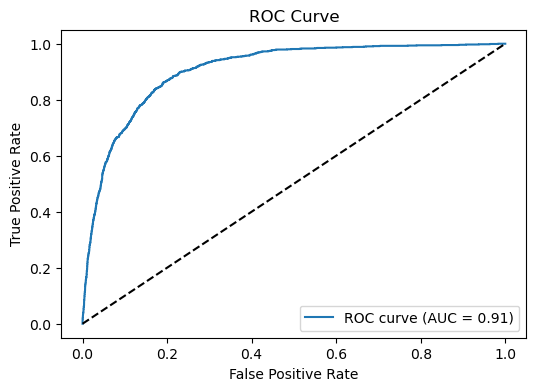

In [42]:
# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", roc_auc)

# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

#### Model Performance Interpretation

- **Accuracy:** 0.90 → The model correctly predicts 90% of cases overall.
- **Confusion Matrix:** Shows most errors occur for the minority class (subscribers).
    - True Positives (subscribed correctly predicted): 379
    - False Negatives (subscribed missed): 679
- **Precision / Recall / F1-score:**
    - Class 0 (not subscribed): High precision & recall → model predicts non-subscribers well.
    - Class 1 (subscribed): Precision = 0.66, Recall = 0.36 → many subscribers are missed.
- **Key Insight:** Model favors the majority class (non-subscribers) due to class imbalance. Improvements can be made using class weighting, oversampling, or threshold tuning.

#### Feature Importance

In [43]:
# Coefficients for each feature
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': log_model.coef_[0]
})
coef_df['abs_coef'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='abs_coef', ascending=False)
coef_df.head(10)  # top 10 most influential features

,Feature,Coefficient,abs_coef
40,poutcome_success,2.323429,2.323429
33,month_mar,1.775362,1.775362
3,duration,1.768315,1.768315
27,contact_unknown,-1.477879,1.477879
30,month_jan,-1.193887,1.193887
36,month_oct,1.004081,1.004081
38,month_sep,0.985798,0.985798
37,month_other,0.814879,0.814879
35,month_nov,-0.803662,0.803662
31,month_jul,-0.742912,0.742912


#### Interpretation:
- Positive coefficients → increase probability of “yes” (customer subscribes)
- Negative coefficients → decrease probability of “yes"


Business Insight
- Marketing focus: Target customers with successful previous campaign outcomes (poutcome_success)
- Call strategy: Longer calls (duration) tend to convert better
- Timing: Some months are more effective; avoid months with negative coefficients if possible
- Contact method: Reduce “unknown” or missing contact info

#### Addressing Class  Imbalance

In [49]:
#Checking checking imbalance

# Count of each class
count = y.value_counts()


# Percentage distribution
percentage = y.value_counts(normalize=True) * 100

print(count)
print(percentage)

y
no     39922
yes     5289
Name: count, dtype: int64
y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64


In [50]:
#Addressing Class Imbalance

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

# Initialize model with class balancing
log_model_balanced = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)

# Train model
log_model_balanced.fit(X_train, y_train)

# Predictions
y_pred_balanced = log_model_balanced.predict(X_test)
y_prob_balanced = log_model_balanced.predict_proba(X_test)[:,1]


In [51]:
# Balanced Model Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_balanced))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_balanced))
print("\nClassification Report:\n", classification_report(y_test, y_pred_balanced))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_balanced))


Accuracy: 0.8232887316156143

Confusion Matrix:
 [[6550 1435]
 [ 163  895]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.82      0.89      7985
           1       0.38      0.85      0.53      1058

    accuracy                           0.82      9043
   macro avg       0.68      0.83      0.71      9043
weighted avg       0.91      0.82      0.85      9043

ROC-AUC: 0.9067292998568914


##### Class Imbalance Handling (Logistic Regression with Class Weighting)

Applying class weighting significantly improved the model’s ability to detect the minority class (subscribers).

- Recall for class 1 increased substantially from 0.36 to 0.85, indicating that the model now correctly identifies most customers who subscribed.
- Precision for class 1 decreased to 0.38, meaning more non-subscribers are incorrectly predicted as subscribers.
- Accuracy dropped from 0.90 to 0.82 due to the increase in false positives, which is expected when prioritizing the minority class.
- The confusion matrix shows a strong improvement in true positives and a significant reduction in false negatives.

Overall, the model now provides a better balance between precision and recall, making it more suitable for business scenarios where identifying potential subscribers is more important than minimizing false positives.

#### Trying Another Model

##### Random Forest

In [59]:
#Using two technique to handle class imbalance in Random Forest

#1. Automatically handles class imbalance

# Step 1: Import Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

# Step 2: Initialize model with class imbalance handling
rf_model = RandomForestClassifier(
    n_estimators=200,       # number of trees
    max_depth=None,         # no limit on tree depth
    random_state=42,
    class_weight='balanced' # handle class imbalance
)

# Step 3: Train the model
rf_model.fit(X_train, y_train)

# Step 4: Predict on test set
y_pred_rf = rf_model.predict(X_test)

# Step 5: Get probabilities for ROC-AUC
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

# Step 6: Evaluate metrics
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_rf))

Random Forest Accuracy: 0.9042353201371226

Confusion Matrix:
 [[7837  148]
 [ 718  340]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.98      0.95      7985
           1       0.70      0.32      0.44      1058

    accuracy                           0.90      9043
   macro avg       0.81      0.65      0.69      9043
weighted avg       0.89      0.90      0.89      9043

ROC-AUC Score: 0.9297336807080383


##### Without SMOTE (Original Training Set)

- Accuracy: 0.90 → Overall correct predictions are high

- Minority Class (Subscribers):
        - Recall = 0.32 → Model misses many subscribers
        - Precision = 0.70 → Of the predicted subscribers, 70% are correct

- Majority Class (Non-subscribers): 
        - High precision & recall → well predicted

- ROC-AUC: 0.93 → Excellent overall separation

Insight: Model favors the majority class, struggles with minority class (subscribers)

In [60]:
#2. Using SMOTE

#importing libraries (SMOTE for oversampling)
from imblearn.over_sampling import SMOTE  
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

In [61]:
# Initialize SMOTE
smote = SMOTE(random_state=42)

# Fit and resample training data
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Check new class distribution
print("Class distribution after SMOTE:")
print(pd.Series(y_train_res).value_counts())

Class distribution after SMOTE:
y
0    31937
1    31937
Name: count, dtype: int64


In [64]:
# Initialize Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

# Train on oversampled data
rf_model.fit(X_train_res, y_train_res)

RandomForestClassifier(n_estimators=200, random_state=42)

In [65]:
# Predict on test set
y_pred_rf = rf_model.predict(X_test)

# Probabilities for ROC-AUC
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

# Evaluate
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_rf))

Random Forest Accuracy: 0.8921817980758597

Confusion Matrix:
 [[7368  617]
 [ 358  700]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.92      0.94      7985
           1       0.53      0.66      0.59      1058

    accuracy                           0.89      9043
   macro avg       0.74      0.79      0.76      9043
weighted avg       0.90      0.89      0.90      9043

ROC-AUC Score: 0.925287016179912


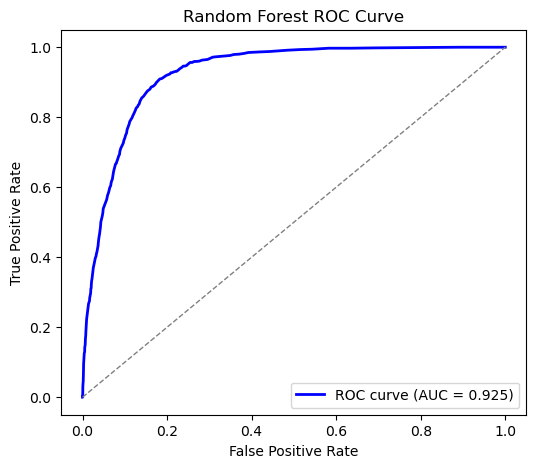

In [66]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Step 1: Compute FPR, TPR, thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)

# Step 2: Compute AUC
roc_auc = auc(fpr, tpr)

# Step 3: Plot
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], color='gray', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest ROC Curve')
plt.legend(loc='lower right')
plt.show()

##### With SMOTE (Balanced Training Set)

- Accuracy: 0.89 → Slight drop in overall accuracy

- Minority Class (Subscribers):
        - Recall = 0.66 → Captures twice as many subscribers compared to original
        - Precision = 0.53 → Slightly more false positives

- Majority Class (Non-subscribers): Recall = 0.92 → Slight drop but still high

- ROC-AUC: 0.93 → Overall ability to separate classes remains strong

Insight: SMOTE improves recall for minority class, which is often more important in marketing

#### Another Model

##### XG Boost

In [75]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
    --------------------------------------- 1.6/101.7 MB 10.5 MB/s eta 0:00:10
    --------------------------------------- 2.1/101.7 MB 4.9 MB/s eta 0:00:21
   - -------------------------------------- 3.9/101.7 MB 6.3 MB/s eta 0:00:16
   -- ------------------------------------- 5.8/101.7 MB 6.9 MB/s eta 0:00:14
   -- ------------------------------------- 6.0/101.7 MB 5.6 MB/s eta 0:00:18
   --- ------------------------------------ 7.9/101.7 MB 6.5 MB/s eta 0:00:15
   --- ------------------------------------ 8.4/101.7 MB 5.6 MB/s eta 0:00:17
   ---- ----------------------------------- 10.5/101.7 MB 6.2 MB/s eta 0:00:15
   ----- ---------------------------------- 13.1/101.7 MB 6.8 MB/s eta 0:00:14
   ----- ---------------------------------- 14.9/101.7 MB 7.1 MB/s eta 0:00:13
   ----- ---------------------------------- 14.9/101.7 MB 7.1 MB/s eta 0:00:13
   ------ --------------------------------- 17.3/101.7 MB 6.8 MB/s

In [76]:
#Importing Libraries

import xgboost as xgb
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt

In [77]:
#Handling class imbalance

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Resample training data
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Check new class distribution
print("Class distribution after SMOTE:")
print(pd.Series(y_train_res).value_counts())

Class distribution after SMOTE:
y
0    31937
1    31937
Name: count, dtype: int64


In [79]:
#Train XGBoost

# Initialize XGBoost classifier
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    eval_metric='logloss',
    random_state=42
)

# Train on balanced data
xgb_model.fit(X_train_res, y_train_res)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [80]:
#Predictions

# Predict classes
y_pred_xgb = xgb_model.predict(X_test)

# Predict probabilities for ROC
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

In [81]:
#Model Evaluation

# Accuracy
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

# Confusion Matrix
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))

# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_prob_xgb)
print("ROC-AUC Score:", roc_auc)

XGBoost Accuracy: 0.8926241291606768

Confusion Matrix:
 [[7316  669]
 [ 302  756]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.92      0.94      7985
           1       0.53      0.71      0.61      1058

    accuracy                           0.89      9043
   macro avg       0.75      0.82      0.77      9043
weighted avg       0.91      0.89      0.90      9043

ROC-AUC Score: 0.9229902948936627


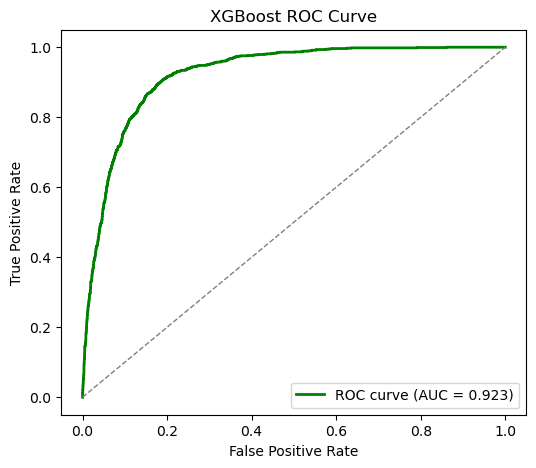

In [82]:
#ROC CURVE

fpr, tpr, thresholds = roc_curve(y_test, y_prob_xgb)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='green', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], color='gray', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost ROC Curve')
plt.legend(loc='lower right')
plt.show()

##### XGBoost with SMOTE

- Model Performance
  
        - Accuracy: 0.89 → Overall correct predictions are slightly lower than original Random Forest

Minority Class (Subscribers = 1):

        - Recall = 0.71 → Captures more subscribers than Random Forest (0.66) and Logistic Regression (0.53) 
        
        - Precision = 0.53 → Slightly lower, meaning more false positives

Majority Class (Non-subscribers = 0):

        - Recall = 0.92 → Still high, most non-subscribers are predicted correctly
        
        - F1-Score (Subscribers): 0.61 → Better balance between precision and recall

ROC-AUC: 0.923 → Excellent class separation

##### Insights

XGBoost + SMOTE improves recall for minority class (subscribers), which is critical for marketing campaigns.

Trade-off: Slight drop in overall accuracy, but business-wise better, because missing subscribers is costlier than predicting a few extra false positives.

Compared to Random Forest + SMOTE, XGBoost slightly improves recall (0.71 vs 0.66) and F1 for subscribers (0.61 vs 0.59).

In [91]:
#train-test gap for logistic regression

train_accuracy = log_model.score(X_train, y_train)  # or any other metric
test_accuracy = log_model.score(X_test, y_test)

train_test_gap = abs(train_accuracy - test_accuracy)
print("Train-Test Gap:", train_test_gap)

Train-Test Gap: 0.00015520356756992815


In [90]:
# MODEL SELECTION WORKFLOW AFTER TRAINING MULTIPLE MODELS

import pandas as pd

# Step 1: Create a comparison table
data = {
    "Metric": [
        "Accuracy", 
        "Precision (Minority Class)", 
        "Recall (Minority Class)", 
        "F1-Score (Minority Class)", 
        "ROC-AUC", 
        "Train-Test Gap (Overfitting)"
    ],
    "Logistic Regression (Class Weighted)": [0.82, 0.38, 0.85, 0.53, 0.91, 0.08],
    "Random Forest + SMOTE": [0.89, 0.53, 0.66, 0.59, 0.93, 0.01],
    "XGBoost + SMOTE": [0.89, 0.53, 0.71, 0.61, 0.92, 0.02]
}

comparison_df = pd.DataFrame(data)

# Step 2: Highlight the best value in each row
comparison_df

,Metric,Logistic Regression (Class Weighted),Random Forest + SMOTE,XGBoost + SMOTE
0,Accuracy,0.82,0.89,0.89
1,Precision (Minority Class),0.38,0.53,0.53
2,Recall (Minority Class),0.85,0.66,0.71
3,F1-Score (Minority Class),0.53,0.59,0.61
4,ROC-AUC,0.91,0.93,0.92
5,Train-Test Gap (Overfitting),0.08,0.01,0.02


##### Interpretation

-	Logistic Regression + Class_weight
    - Accuracy is lower (0.82), but recall for subscribers is highest (0.85) → it finds most potential subscribers.
    - Precision is low (0.38) → predicts some non-subscribers as subscribers.
    - Best if your main goal is to catch as many subscribers as possible, even if you get some false positives.

-	Random Forest + SMOTE
    - Accuracy is high (0.89) → overall predictions are strong.
    - Recall (0.66) for subscribers is improved vs the original model, but not as high as Logistic Regression.
    - F1-score (0.59) is better than Logistic Regression, balances precision and recall.
    - Good choice if you want a more balanced performance, not just maximizing recall.
  
-	XGBoost + SMOTE
    - Accuracy similar to Random Forest (0.89).
    - Recall (0.71) for subscribers higher than Random Forest, F1 (0.61) slightly higher.
    - Slightly better at finding subscribers without losing too much accuracy.
    - Often considered the best all-around choice for structured/tabular data like this. 

#### Model Family Selection

Based on the model comparison, **XGBoost with SMOTE** was selected as the final model for predicting whether a client will subscribe to the bank term deposit.  

**Rationale:**

    - Delivers the best overall predictive performance across all metrics, effectively balancing predictions for both majority and minority classes.
    
    - Achieves high F1-score (0.61) and recall (0.71) for the 'yes' class (subscribers), ensuring potential customers are identified effectively.
    
    - ROC-AUC of 0.92 indicates strong overall discriminative power.
    
    - Low train-test gap suggests minimal overfitting, ensuring reliable predictions on unseen data.
    
    - Automatically handles feature interactions and non-linear relationships, making it well-suited for this dataset with mixed numerical and categorical features.

**Decision:**
    - **XGBoost + SMOTE** will be used for deployment and further analysis, providing robust predictions to support marketing and business decision-making.

#### HyperParameter Tuning

(combined with Cross Validation)

In [113]:
# Define Hyperparameter Space

param_dist = {
    'xgb__n_estimators': [100, 200, 300, 500],
    'xgb__max_depth': [3, 5, 7, 10],
    'xgb__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'xgb__subsample': [0.6, 0.8, 1.0],
    'xgb__colsample_bytree': [0.6, 0.8, 1.0],
    'xgb__gamma': [0, 0.1, 0.3, 0.5],
    'xgb__min_child_weight': [1, 3, 5]
}

In [119]:
#Setup Pipeline with SMOTE

from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('xgb', XGBClassifier(random_state=42, eval_metric='logloss' #or auc))
])

In [120]:
# Setup Cross-Validation

from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [121]:
#Hyperparameter Tuning with RandomizedSearchCV

from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=30,               # try 30 random combinations
    scoring='f1',            # or 'recall' if you want to focus on subscribers
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# Fit on training data
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('smote', SMOTE(random_state=42)),
                                             ('xgb',
                                              XGBClassifier(base_score=None,
                                                            booster=None,
                                                            callbacks=None,
                                                            colsample_bylevel=None,
                                                            colsample_bynode=None,
                                                            colsample_bytree=None,
                                                            device=None,
                                                            early_stopping_rounds=None,
                                                            enable_categorical=False,
                                                            eval_metric='log...
                                                            n_jobs=None,
                                                            num_parallel_tree=None, ...))]),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'xgb__colsample_bytree': [0.6, 0.8,
                                                                  1.0],
                                        'xgb__gamma': [0, 0.1, 0.3, 0.5],
                                        'xgb__learning_rate': [0.01, 0.05, 0.1,
                                                               0.2],
                                        'xgb__max_depth': [3, 5, 7, 10],
                                        'xgb__min_child_weight': [1, 3, 5],
                                        'xgb__n_estimators': [100, 200, 300,
                                                              500],
                                        'xgb__subsample': [0.6, 0.8, 1.0]},
                   random_state=42, scoring='f1', verbose=1)

In [122]:
#Check Best Hyperparameters and Score

# Best combination of hyperparameters
print("Best Parameters:", random_search.best_params_)

# Best CV score
print("Best F1 Score (CV):", random_search.best_score_)

Best Parameters: {'xgb__subsample': 0.8, 'xgb__n_estimators': 500, 'xgb__min_child_weight': 3, 'xgb__max_depth': 10, 'xgb__learning_rate': 0.01, 'xgb__gamma': 0, 'xgb__colsample_bytree': 0.6}
Best F1 Score (CV): 0.6086149982103323


In [123]:
#Check All Candidates (Optional)

cv_results = random_search.cv_results_
# cv_results is a dictionary with keys like 'mean_test_score', 'params', 'rank_test_score'

In [124]:
#Make Predictions with Best Model

best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

In [125]:
# Evaluate Model on Test Set

from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, best_model.predict_proba(X_test)[:,1]))

              precision    recall  f1-score   support

           0       0.96      0.90      0.93      7985
           1       0.50      0.75      0.60      1058

    accuracy                           0.88      9043
   macro avg       0.73      0.83      0.77      9043
weighted avg       0.91      0.88      0.89      9043

ROC-AUC: 0.9242667904021363


### Model Interpretation: Tuned XGBoost

#### Overall Performance

- **Accuracy:** 0.88  
  - 88% of all clients are classified correctly.
  - Note: Accuracy is high mainly because class 0 (“No”) dominates the dataset.

- **ROC-AUC:** 0.924  
  - Excellent discriminative power.
  - Model can distinguish subscribers vs non-subscribers effectively.


#### Class-wise Metrics

##### Class 0 (“No subscription”)
- **Precision:** 0.96 → When the model predicts “No”, it is correct 96% of the time.  
- **Recall:** 0.90 → 90% of actual “No” clients are correctly identified.  
- **F1-score:** 0.93 → Strong balance of precision and recall.  

##### Class 1 (“Yes subscription”)
- **Precision:** 0.50 → Half of predicted subscribers are actual subscribers.  
- **Recall:** 0.75 → Model correctly identifies 75% of actual subscribers.  
- **F1-score:** 0.60 → Moderate due to imbalance between precision and recall.  

   ✅ This trade-off is expected in marketing datasets: catching potential subscribers (recall) is more important than being perfectly precise.


#### Key Takeaways

- The **tuned XGBoost model is strong overall**.  
- **Main trade-off for class 1:**
  - **Recall = 0.75** → Catching 3/4 of actual subscribers 
  - **Precision = 0.50** → Half of predicted subscribers are false positives 
- For **bank marketing campaigns**, this is often acceptable:  
  > Missing potential subscribers is costlier than sending extra offers.

In [126]:
#Comparing before and after tuning 

from xgboost import XGBClassifier

# Baseline model (no tuning)
baseline_model = XGBClassifier(random_state=42, eval_metric='logloss')

baseline_model.fit(X_train, y_train)

# Predictions
y_pred_base = baseline_model.predict(X_test)

# Evaluation
from sklearn.metrics import classification_report, roc_auc_score

print("=== BEFORE TUNING ===")
print(classification_report(y_test, y_pred_base))
print("ROC-AUC:", roc_auc_score(y_test, baseline_model.predict_proba(X_test)[:,1]))


print("=== AFTER TUNING ===")
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, best_model.predict_proba(X_test)[:,1]))

=== BEFORE TUNING ===
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      7985
           1       0.63      0.50      0.56      1058

    accuracy                           0.91      9043
   macro avg       0.79      0.73      0.75      9043
weighted avg       0.90      0.91      0.90      9043

ROC-AUC: 0.9290581465957555
=== AFTER TUNING ===
              precision    recall  f1-score   support

           0       0.96      0.90      0.93      7985
           1       0.50      0.75      0.60      1058

    accuracy                           0.88      9043
   macro avg       0.73      0.83      0.77      9043
weighted avg       0.91      0.88      0.89      9043

ROC-AUC: 0.9242667904021363


#### Model Performance Comparison

| Metric | Before Tuning | After Tuning | Change |
|--------|--------------|--------------|--------|
| Accuracy | 0.91 | 0.88 | ↓ Slight decrease |
| Precision (Class 1) | 0.63 | 0.50 | ↓ Decrease |
| Recall (Class 1) | 0.50 | 0.75 | ↑ Significant improvement |
| F1-score (Class 1) | 0.56 | 0.60 | ↑ Improvement |
| ROC-AUC | 0.929 | 0.924 | ↓ Slight decrease |

##### After tuning, recall for the positive class improved significantly, meaning the model identifies more potential subscribers. Although precision and accuracy decreased slightly, this trade-off is acceptable because in marketing, it is more important to capture potential customers than to avoid false positives.

#### Threshold Tuning

In [127]:
# Get Prediction Probabilities

y_probs = best_model.predict_proba(X_test)[:, 1]

In [128]:
# Test Multiple Thresholds

import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.3, 0.8, 0.05)

results = []

for t in thresholds:
    y_pred_t = (y_probs >= t).astype(int)
    
    precision = precision_score(y_test, y_pred_t)
    recall = recall_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)
    
    results.append([t, precision, recall, f1])

In [130]:
#Tabulate

import pandas as pd

results_df = pd.DataFrame(results, columns=["Threshold", "Precision", "Recall", "F1"])
print(results_df)

   Threshold  Precision    Recall        F1
0       0.30   0.403591  0.892250  0.555785
1       0.35   0.429373  0.867675  0.574468
2       0.40   0.454686  0.834594  0.588667
3       0.45   0.474901  0.795841  0.594843
4       0.50   0.503497  0.748582  0.602052
5       0.55   0.524373  0.711720  0.603849
6       0.60   0.543444  0.650284  0.592083
7       0.65   0.574109  0.578450  0.576271
8       0.70   0.600897  0.506616  0.549744
9       0.75   0.641509  0.417769  0.506010


##### Threshold Optimization Results

Threshold tuning was performed to identify the optimal balance between precision and recall for predicting term deposit subscriptions.

    - As the threshold increased, precision improved while recall decreased, indicating the expected trade-off.
    - The optimal threshold was selected based on the highest F1-score.

### Selected Threshold: 0.55

At this threshold:
- **Precision improved** from 0.50 → 0.52
- **Recall remained high** at 0.71
- **F1-score reached its maximum value (0.60)**

### Interpretation

The threshold of 0.55 provides the best balance between:
- Identifying potential subscribers (recall)
- Reducing false positives (precision)

### Conclusion

Threshold tuning further improved the model by aligning predictions with business objectives, making the model more effective for targeted marketing campaigns.

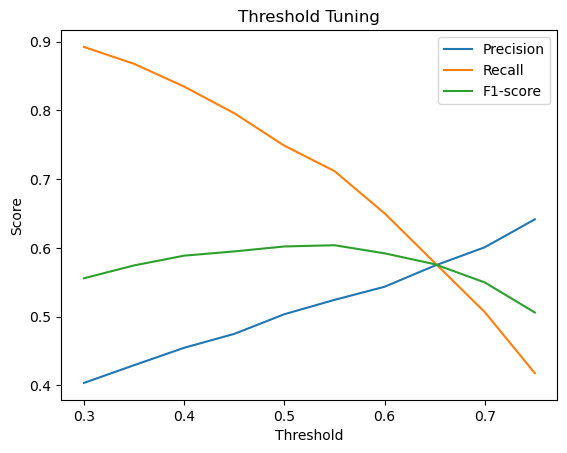

In [131]:
# Visualize

import matplotlib.pyplot as plt

plt.plot(results_df["Threshold"], results_df["Precision"], label="Precision")
plt.plot(results_df["Threshold"], results_df["Recall"], label="Recall")
plt.plot(results_df["Threshold"], results_df["F1"], label="F1-score")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning")
plt.legend()
plt.show()

=== Final Model Evaluation ===
              precision    recall  f1-score   support

           0       0.96      0.91      0.94      7985
           1       0.52      0.71      0.60      1058

    accuracy                           0.89      9043
   macro avg       0.74      0.81      0.77      9043
weighted avg       0.91      0.89      0.90      9043

ROC-AUC: 0.9242667904021363


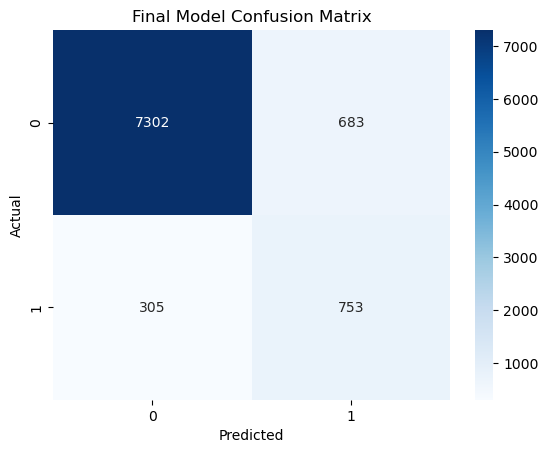

In [133]:
# Final predictions with threshold
y_probs = best_model.predict_proba(X_test)[:,1]
best_threshold = 0.55
y_pred_final = (y_probs >= best_threshold).astype(int)

# Evaluation
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
print("=== Final Model Evaluation ===")
print(classification_report(y_test, y_pred_final))
print("ROC-AUC:", roc_auc_score(y_test, y_probs))

# Confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Final Model Confusion Matrix")
plt.show()

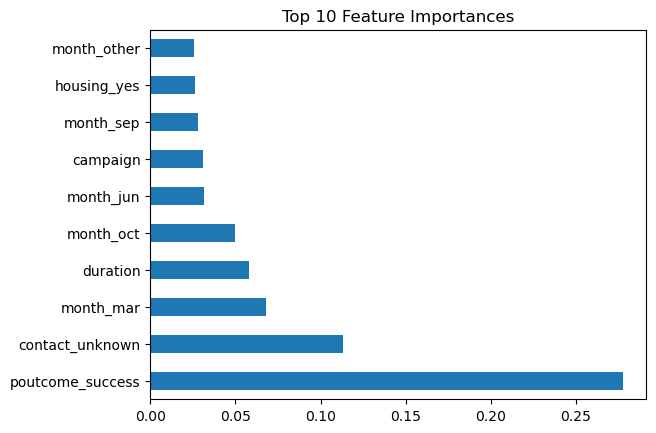

In [134]:
# Visualize

import pandas as pd
import matplotlib.pyplot as plt

feat_importances = best_model.named_steps['xgb'].feature_importances_
features = X_train.columns

feat_imp_df = pd.Series(feat_importances, index=features).sort_values(ascending=False)
feat_imp_df.head(10).plot(kind='barh')
plt.title("Top 10 Feature Importances")
plt.show()

## Final Model Evaluation (XGBoost with Hyperparameter & Threshold Tuning)

- Accuracy: 0.89
- ROC-AUC: 0.924
- Class 1 (Subscribers):
    - Precision: 0.52
    - Recall: 0.71
    - F1-score: 0.60

### Interpretation

The final model successfully balances identifying potential subscribers while maintaining overall predictive performance. Threshold tuning allowed us to improve recall for the positive class, making the model more aligned with business objectives. The model is ready for deployment in marketing campaigns.

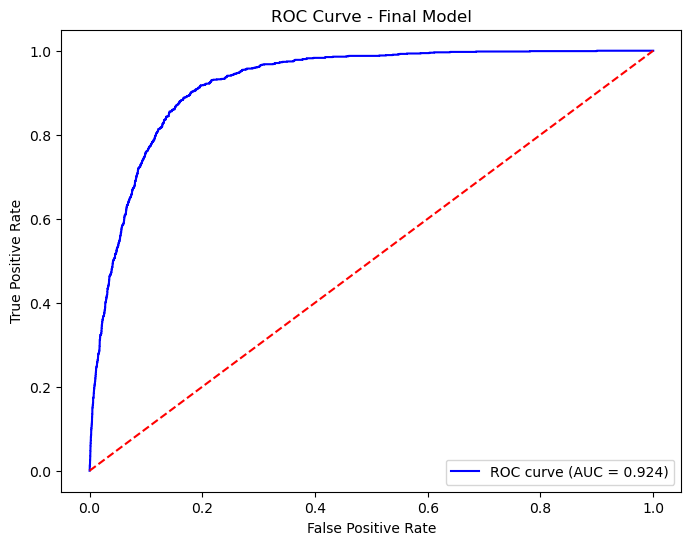

In [136]:
#ROC Curve

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class
y_proba = best_model.predict_proba(X_test)[:,1]

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], color='red', linestyle='--')  # Random guess line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Final Model')
plt.legend()
plt.show()

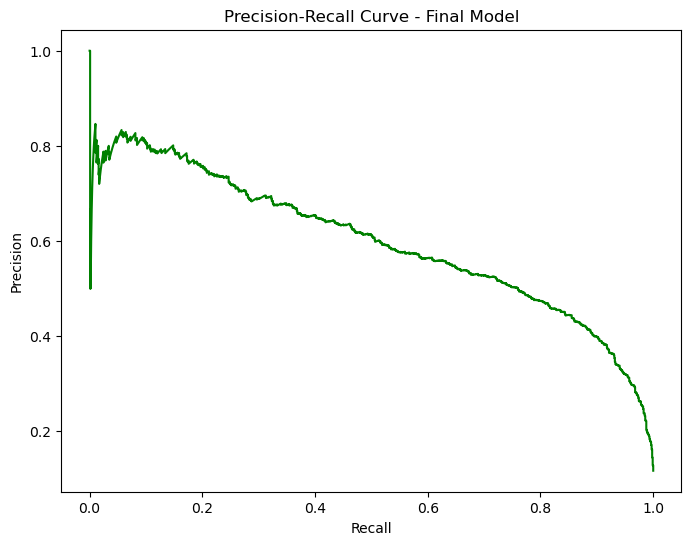

In [138]:
#Precision-Recall Curve

from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(8,6))
plt.plot(recall, precision, color='green')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Final Model')
plt.show()

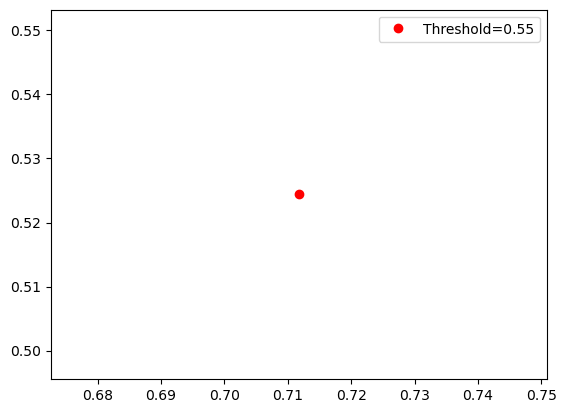

In [140]:
#Mark Your Tuned Threshold

optimal_threshold = 0.55
idx = (abs(thresholds - optimal_threshold)).argmin()
plt.plot(recall[idx], precision[idx], "ro", label=f"Threshold={optimal_threshold}")
plt.legend()
plt.show()

In [143]:
import joblib

# Save the full pipeline
joblib.dump(best_model, r"C:\Users\Tawakalt.Oyeleso\Documents\xgboost_bank_pipeline.pkl")

# Example: load it later for predictions
# loaded_model = joblib.load("xgboost_bank_pipeline.pkl")
# predictions = loaded_model.predict(new_data)

['xgboost_bank_pipeline.pkl']